#Properties of Complex Systems in Sensor Data From MmCows: Dairy Cows Dataset

In this notebook, we will test the assumption of complexity in the sensor data from the MmCows dataset in order to assess the validity of the application of complex systems methods for its analysis.

Before testing for these properties, it is important to establish why cow behavior, and specifically ankle acceleration, might operate as a complex system. A cow is a dynamic biological organism whose movements are the result of numerous interacting subsystems. These include physiological states (e.g. circadian rhythms, digestion cycles) and environmental conditions (e.g. barn temperature, social dynamics, feeding schedules). Because of these interactions, we hypothesize that a cow's physical activity is not random noise, but rather exhibits complex dynamics.

Following Olthof et al. (2020), we search for the presence of two properties of complex systems in the data. Olthof et al. (2020) examine whether time series data of psychological self-ratings exhibits three relevant complex system markers:

1. Memory - are there short- and long-range temporal correlations?
2. Regime shifts - are there transitions between different attractor states?
3. Sensitivity to initial conditions - does the future trajectory strongly depend on the initial conditions?

We check for the first two properties, seeing as the third is out of the scope of this entry. We will conduct statistical testing to identify the (lack of) existence of the two properties, and interpret them.

The MmCows dataset has time series sensor data from a variety of wearable sensors used on the cows. In this notebook, we focus on ankle acceleration as an indication of the cows' movements. We showcase the analysis on this data alone for the sake of illustrating the proper methods. However, the analysis here was run on the other data used in the portfolio, and we selected the data whose properties matched the ones of ankle acceleration as closely as possible, for the sake of consistency.

##Data Loading and Plotting

Let us begin by loading the ankle acceleration data. Each cow has an ankle sensor measuring the ankle's acceleration in the x, y and z direction of 3D space at a given point in time. The data is collected over 14 days, every 60 seconds. There are ten cows that wore the sensor, and each cow has a separate file with its data. We will conduct our analysis on a cow-level seeing as a time series of accelerations belongs to a particular cow and how _it_ moves.

In [ ]:
file_paths = list.files(path="data/sensor_data/sub_data/ankle_accel/", pattern="\\.csv$", full.names = TRUE)

list_files = list()
for (i in 1:length(file_paths)) {
  var_name <- tools::file_path_sans_ext(basename(file_paths[i]))

  # creates dataframes with original names of csv files
  assign(var_name, read.csv(file_paths[i]))
  list_files <- append(list_files, var_name)
}

# show dataframe of one cow
head(get(list_files[[i]]))

,timestamp,accel_x,accel_y,accel_z
,<int>,<dbl>,<dbl>,<dbl>
1,1689960600,0.200,-1.000,-0.175
2,1689960660,0.300,-0.925,-0.225
3,1689960720,0.200,-1.000,-0.175
4,1689960780,0.300,-0.925,-0.250
5,1689960840,0.325,-0.950,-0.275
6,1689960900,0.375,-0.875,-0.175


Now we check for missing values since some of the tests require no missing values. As we can see in the output, there are no missing values in any of the columns, for any of the cows.



In [ ]:
# loop through dataframes and alert if the number of missing values per column is != 0 anywhere
for (i in 1:length(list_files)){
  if(colSums(is.na(get(list_files[[i]])))[["accel_x"]] || colSums(is.na(get(list_files[[i]])))[["accel_y"]] || colSums(is.na(get(list_files[[i]])))[["accel_z"]]){
    print("There are missing values.")
  }
}

To get acquainted with the data, we plot it. We show a random cow's plot for acceleration in the x axis. The timestamp is not fully interpretable but we are more interested in the acceleration and its development over time. In general, the acceleration values for all cows are within the interval [-4, 4], but the dataset description does not mention the unit of these values.

The data for cow 8 appears chaotic, without a clear pattern. Towards the middle the values become sporadically more extreme and this continues until the end of the time period. This could indicate the cow was moving more or more quickly. By checking this cow's health records, we did not find any recorded reason for greater inactivity at the beginning of the measurement period.



In [ ]:
require(ggplot2)

# loop through all cows and plot the x axis of their acceleration
# for (i in 1:length(list_files)){
#   print(ggplot(data = get(list_files[[i]]), mapping = aes(timestamp, accel_x)) + geom_line() + ggtitle("Accel_X vs. Timestamp for One Cow"))

# }

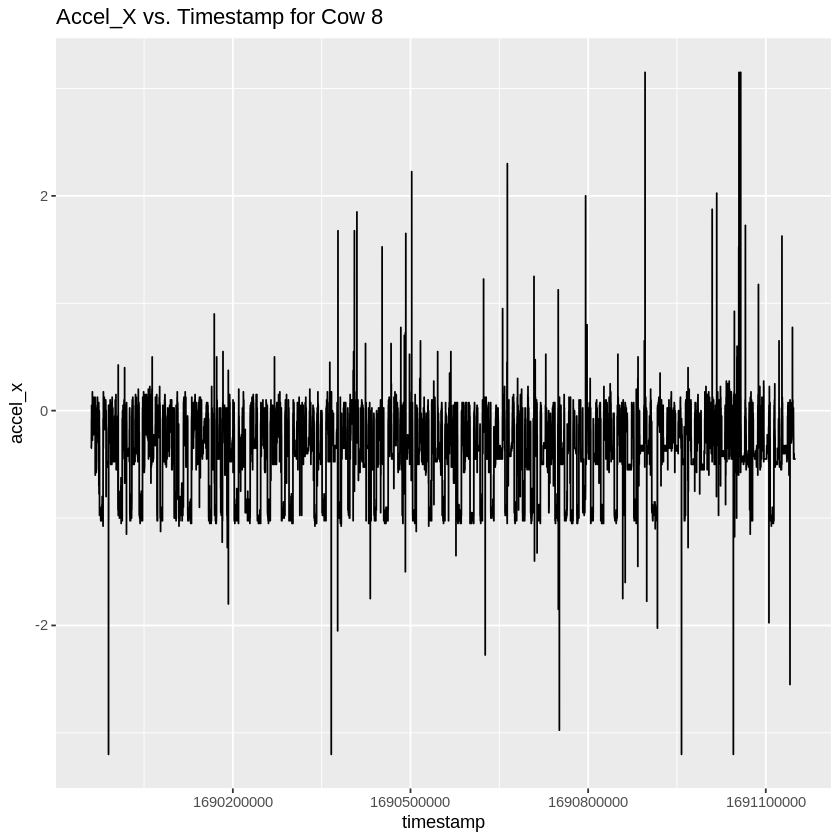

In [ ]:
print(ggplot(data = get(list_files[[8]]), mapping = aes(timestamp, accel_x)) + geom_line() + ggtitle("Accel_X vs. Timestamp for Cow 8"))


With the plotting, we end our short data exploration and begin testing for the memory property.

##Memory

Memory can be seen in time series as the dependence of current values on past ones. Statistically, this manifests as non-randomness in the time series (Olthof et al., 2020). Randomness can be tested for using Bartels rank test. The null-hypothesis is that the time series is random. For this statistical test and all the ones that follow, we followed Olthof et al. (2020) and corrected for multiple testing with Bonferroni correction. So the alpha level of .05 was divided by 10*3 for the ten cows and the three axes tested. Therefore, a result is significant when p < .002.

Yet again, we show the results for cow 8, but the results for all other cows have the same p-values.

In [ ]:
install.packages("randtests")
require(randtests)

# loop through all cows and test against randomness for each axis
# for (i in 1:length(list_files)){

#   # extract the proper p-values
#   p_val_x <- randtests::bartels.rank.test(get(list_files[[i]])$accel_x, alternative = "two.sided")$p.value
#   p_val_y <- randtests::bartels.rank.test(get(list_files[[i]])$accel_y, alternative = "two.sided")$p.value
#   p_val_z <- randtests::bartels.rank.test(get(list_files[[i]])$accel_z, alternative = "two.sided")$p.value

#   # format the p-values
#   formatted_p_vals <- format.pval(c(p_val_x, p_val_y, p_val_z), eps = 2.2e-16)

#   # make a table
#   results_table <- data.frame(
#     Axis = c("X", "Y", "Z"),
#     `p-value` = formatted_p_vals,
#     check.names = FALSE
#   )

#   # print the headers and the table
#   cat("################################################\n")
#   cat("Bartels Rank Test Results for Cow", list_files[[i]], "\n")
#   print(results_table)
#   cat("\n") # Adds an empty line for readability between cows
# }

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# extract the proper p-values for cow 8
p_val_x <- randtests::bartels.rank.test(get(list_files[[8]])$accel_x, alternative = "two.sided")$p.value
p_val_y <- randtests::bartels.rank.test(get(list_files[[8]])$accel_y, alternative = "two.sided")$p.value
p_val_z <- randtests::bartels.rank.test(get(list_files[[8]])$accel_z, alternative = "two.sided")$p.value

# format the p-values
formatted_p_vals <- format.pval(c(p_val_x, p_val_y, p_val_z), eps = 2.2e-16)

# make a table
results_table <- data.frame(
  Axis = c("X", "Y", "Z"),
  `p-value` = formatted_p_vals,
  check.names = FALSE
)

# print the table
cat("Bartels Rank Test Results for Cow", list_files[[8]], "\n")
results_table

Bartels Rank Test Results for Cow C08 


Axis,p-value
<chr>,<chr>
X,< 2.2e-16
Y,< 2.2e-16
Z,< 2.2e-16


Seeing as all the p-values are <.002, there is sufficient evidence for non-randomness of the acceleration in all axes for all cows.

Apart from general dependence on past values, we can look at short-range and long-range correlations as an indication of memory. Short-range correlations can be seen at low time lag values, whereas long-range correlations can be investigated using the autocorrelation function (ACF). A plot of the ACF is a visual way of showing the correlation strength against the lag, giving us a view of the short- and long-range correlations simultaneously.

Further, the number of significant partial autocorrelations - where correlation values at higher lags are corrected for autocorrelation at lower lags - can be used fo quantify long-range correlations. The significance threshold for the partial autocorrelations is determined by the significance level (0.2%) and the two-tailed Z test with the time series length as the number of observations (Olthof et al., 2020).

We provide the full results below, and only show the plot of the PACF for cow 8 and the x axis. In general, each cow and axis has multiple significant partial autocorrelations (>5), and they are found at very high lags, usually more than 500. The low lags usually have significant autocorrelations, too. One notable exception is cow C05 whose first three lags in the z axis are the only ones with significant partial autocorrelations.

Therefore, we conclude both short- and long-range temporal correlations are generally present in the examined time series.  


In [ ]:
# empty data frame to store the results
pacf_results <- data.frame(
  `Cow Number` = character(),
  Axis = character(),
  `PACF above threshold` = integer(),
  `Max lag above threshold` = numeric(),
  check.names = FALSE
)

# loop through all cows
for (i in 1:length(list_files)){
  cow_num <- list_files[[i]]

  # loop through the three axes
  for (axis in c("x", "y", "z")) {
    col_name <- paste0("accel_", axis)
    ts_data <- get(cow_num)[[col_name]]

    # determine length of time series and threshold
    N <- length(ts_data)
    threshold <- 3.09 / sqrt(N)

    # calculate PACF with plot = FALSE to stop the plotting
    pacf_obj <- pacf(na.exclude(ts_data), lag.max=1000, plot=FALSE)

    # find lags above the threshold
    lags_above <- which(abs(pacf_obj$acf) > threshold)

    # calculate how many lags above threshold and max lag above threshold
    count_above <- length(lags_above)
    max_lag <- ifelse(length(lags_above) > 0, max(lags_above), NA)

    # make a new row for this specific cow and axis
    new_row <- data.frame(
      `Cow Number` = cow_num,
      Axis = toupper(axis),
      `PACF above threshold` = count_above,
      `Max lag above threshold` = max_lag,
      check.names = FALSE
    )
    pacf_results <- rbind(pacf_results, new_row)
  }
}

print("#############################################")
print("PACF Summary Table")
pacf_results

[1] "#############################################"
[1] "PACF Summary Table"


Cow Number,Axis,PACF above threshold,Max lag above threshold
<chr>,<chr>,<int>,<int>
C01,X,14,870
C01,Y,8,651
C01,Z,5,191
C02,X,14,953
C02,Y,6,987
C02,Z,6,581
C03,X,13,912
C03,Y,5,100
C03,Z,6,573


[1] "Results for Cow C08"
[1] "X axis:"
[1] "Number of values of PACF above the two-tailed Z test threshold: 12"
[1] "Max lag value greater than the threshold: 597"


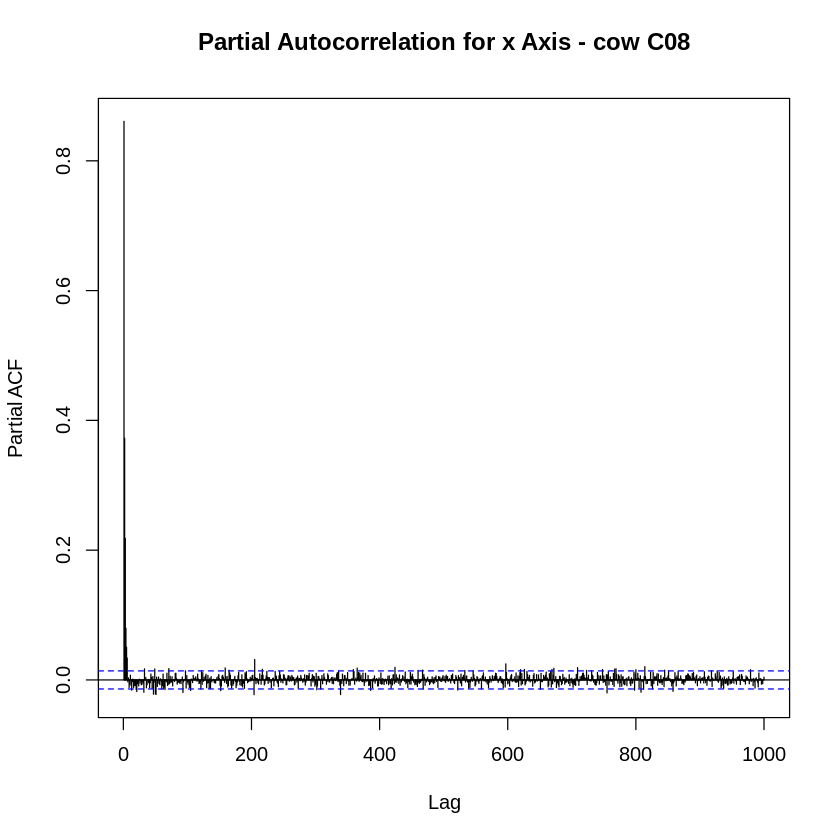

In [ ]:
print(paste0("Results for Cow ", list_files[[8]]))
print("X axis:")
# determine length of time series
N <- length(get(list_files[[8]])$accel_x)

# determine the number of values of the partial autocorrelation function that are above the two-tailed Z test threshold
print(paste0("Number of values of PACF above the two-tailed Z test threshold: ",length(which(abs(pacf(na.exclude(get(list_files[[8]])$accel_x),lag.max=1000, main=paste0("Partial Autocorrelation for x Axis - cow ", list_files[[8]]))$acf)>(3.09 / sqrt(N))))))
# determine the max lag value that is greater than the threshold
print(paste0("Max lag value greater than the threshold: ", max(which(abs(pacf(na.exclude(get(list_files[[8]])$accel_x), lag.max=1000, pl=FALSE)$acf)>(3.09 / sqrt(N))))))


In complex systems, the way things are correlated over time isn't constant. This time-varying (or non-stationary) nature of correlations is considered strong evidence for different processes interacting in complex ways across various time scales within the system. This is yet another aspect of the memory of a complex system.

Non-stationarity can be examined in the lag 1 autocorrelation using a time-varying auto-regressive model (TV-AR). This model tests whether a time-varying smoothing function is different from zero. Then the effective degrees of freedom (EDF) shows whether there is a linear trend of the autocorrelations over time (EDF = 2), or if the autocorrelation is non-stationary (EDF > 2) (Olthof et al., 2020).

Our results show that for most cows, there is a linear trend in one of the axes, while the other axes are non-stationary.

Cows' ankle movements are not homogenous across all three axes. One axis might primarily capture a consistent, rhythmic movement (like the main direction of travel), which could show a more linear change in temporal correlations. The other axes, however, might capture more variable, or reactive movements (like sideways adjustments, balancing, or sudden accelerations), which would naturally exhibit more complex, non-stationary correlation patterns. This variability across axes supports the idea that the overall movement system is still complex, with some more stable components.

In [ ]:
library(mgcv)
set.seed(4242)

# empty wide data frame to store the results
edf_results <- data.frame(
  `Cow Number` = character(),
  `EDF for x axis` = numeric(),
  `EDF for y axis` = numeric(),
  `EDF for z axis` = numeric(),
  check.names = FALSE
)

# loop through all cows
for (i in 1:length(list_files)){
  cow_num <- list_files[[i]]
  cow_data <- get(cow_num)

  # temporary vector to hold the 3 EDF values for the current cow
  edfs <- c(x = NA, y = NA, z = NA)

  # loop through the three axes
  for (axis in c("x", "y", "z")) {

    col_name <- paste0("accel_", axis)
    accel_data <- cow_data[[col_name]]

    # make current and lagged series
    y_current <- accel_data[2:length(accel_data)]
    y_lag1 <- accel_data[1:(length(accel_data)-1)]

    # make a time index that matches the length of the lagged series
    tt <- 1:length(y_current)

    # make a data frame for the gam model and run gam model
    model_df <- data.frame(y_current = y_current, y_lag1 = y_lag1, tt = tt)
    tvar <- gam(y_current ~ s(tt, by = y_lag1, k = 10, bs = "tp"), data = model_df)
    stvar <- summary(tvar)

    # save the rounded EDF into the temporary vector for this specific axis
    edfs[axis] <- round(stvar$edf, 3)
  }

  # make a row for this specific cow using the stored vector values
  new_row <- data.frame(
    `Cow Number` = cow_num,
    `EDF for x axis` = edfs["x"],
    `EDF for y axis` = edfs["y"],
    `EDF for z axis` = edfs["z"],
    check.names = FALSE,
    row.names = NULL
  )
  edf_results <- rbind(edf_results, new_row)
}

print("#############################################")
print("EDF Summary Table")
edf_results

[1] "#############################################"
[1] "EDF Summary Table"


Cow Number,EDF for x axis,EDF for y axis,EDF for z axis
<chr>,<dbl>,<dbl>,<dbl>
C01,2.000,3.093,3.559
C02,9.366,7.333,7.402
C03,3.080,2.973,2.719
C04,6.541,6.450,9.795
C05,7.110,2.000,2.000
C06,9.316,2.000,2.700
C07,9.359,2.000,2.000
C08,9.952,2.131,2.766
C09,2.000,2.696,8.149


##Testing Regime Shifts

A complex system has states where things stabilize, i.e. regimes, and in between two or more of these, there is a regime shift. Different regimes have different statistical properties and in between them there is often a period of instability that can be identified through its non-stationarity by the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test (Olthof et al., 2020). The alternative hypothesis of a KPSS test is that the signal deviates from a stationary one.

KPSS in R displays p-values only as low as 0.01. If we evaluate the results using a standard significance threshold of 0.05 (where < 0.01 is definitively significant), we observe distinct groupings within the ten cows:
*   Non-stationary: Only cow C04 shows significant non-stationarity across all three axes (p < 0.01), suggesting frequent or sharp transitions between behavioral states.
*   Stationary: Cows C01, C03, C07, and C10 do not present sufficient evidence to reject the null hypothesis on any axis (all p-values > 0.05).
*   Mixed: Several cows (C02, C05, C06, C08, and C09) show non-stationarity on one or two axes, but remain stationary on others. This indicates that while some elements of their movement shift regimes, other directional movements remain stable.

Given that healthy cows in a controlled barn environment typically follow predictable routines, they may not frequently transition between different physical states. This day-to-day routine likely explains why the KPSS test detects no significant regime shifts for a large portion of the cows.

In [ ]:
# helper function to know if p-value is smaller or greater than the printed one
get_formatted_kpss_pval <- function(series) {
  warn_msg <- ""

  res <- withCallingHandlers(
    tseries::kpss.test(series, lshort=TRUE, null="Level"),
    warning = function(w) {
      warn_msg <<- w$message
      invokeRestart("muffleWarning")
    }
  )

  if (grepl("smaller than printed p-value", warn_msg)) {
    return(paste0("< ", res$p.value))
  } else if (grepl("greater than printed p-value", warn_msg)) {
    return(paste0("> ", res$p.value))
  } else {
    return(format.pval(res$p.value, eps = 2.2e-16))
  }
}

# empty data frame to store the results
kpss_results <- data.frame(
  `Cow Number` = character(),
  `p-value for x axis` = character(),
  `p-value for y axis` = character(),
  `p-value for z axis` = character(),
  check.names = FALSE
)

# loop through all cows
for (i in 1:length(list_files)){
  cow_num <- list_files[[i]]
  cow_data <- get(cow_num)

  # save p-values using the helper function
  fmt_p_val_x <- get_formatted_kpss_pval(cow_data$accel_x)
  fmt_p_val_y <- get_formatted_kpss_pval(cow_data$accel_y)
  fmt_p_val_z <- get_formatted_kpss_pval(cow_data$accel_z)

  # make a new row for this specific cow
  new_row <- data.frame(
    `Cow Number` = cow_num,
    `p-value for x axis` = fmt_p_val_x,
    `p-value for y axis` = fmt_p_val_y,
    `p-value for z axis` = fmt_p_val_z,
    check.names = FALSE
  )
  kpss_results <- rbind(kpss_results, new_row)
}

print("#############################################")
print("KPSS Test Summary Table")
kpss_results

[1] "#############################################"
[1] "KPSS Test Summary Table"


Cow Number,p-value for x axis,p-value for y axis,p-value for z axis
<chr>,<chr>,<chr>,<chr>
C01,> 0.1,0.075083,> 0.1
C02,< 0.01,> 0.1,< 0.01
C03,> 0.1,> 0.1,> 0.1
C04,< 0.01,< 0.01,< 0.01
C05,0.020279,0.042168,> 0.1
C06,0.040383,> 0.1,0.046891
C07,> 0.1,> 0.1,> 0.1
C08,< 0.01,> 0.1,< 0.01
C09,0.012768,> 0.1,< 0.01


###Note on computational limitations
Due to the high-frequency nature of the time series data, evaluating change points using the e.divisive algorithm was computationally unfeasible within available hardware (specifically RAM) constraints. Consequently, this specific analysis was omitted. However, the presence of regime shifts is still captured by our KPSS tests.

##Conclusion

To conclude, our analyses provide partial validation for treating cow ankle acceleration as a complex system. Specifically, the data strongly exhibits the complex system property of memory, while evidence for regime shifts is somewhat limited.

We found statistically significant evidence for non-randomness across all cows and axes, alongside short- and long-range temporal correlations reaching lags of over 500. This confirms the hypothesis that a cow's physical activity is not random noise. Rather, its current movements are dependent on its past states. Furthermore, the varied effective degrees of freedom (EDF) observed in the time-varying autoregressive models (where different axes for the same cow exhibit both linear and non-stationary correlation patterns) highlights that movement is not homogeneous across all the axes and thus exhibits complexity.   

Conversely, the KPSS tests showed that frequent regime shifts are not a universal characteristic of this dataset. While non-stationarity exists, the majority of cows remained stationary on at least one, if not multiple, axes. From a complex systems perspective, this suggests that healthy cows in a controlled environment (like a barn) operate within a single, stable attractor state due to predictable routines.

Ultimately, these analyses tell us that while cow movement operates as a complex system, it is a stable one. We conclude that complex systems methods arevalid for analyzing the memory of the movements. However, researchers should only expect to observe regime shifts when the system is significantly disturbed, such as through illness, injury, or some large environmental changes. Finally, while RAM limitations prevented us from executing the e.divisive algorithm for change point analysis on this dataset, we recognize in hindsight that downsampling the data could have offered a viable computational workaround.

###References

Olthof, M., Hasselman, F. & Lichtwarck-Aschoff, A. Complexity in psychological self-ratings: implications for research and practice. BMC Med 18, 317 (2020). https://doi.org/10.1186/s12916-020-01727-2

James, Nicholas A., and David S. Matteson. "ecp: An R package for nonparametric multiple change point analysis of multivariate data." Journal of Statistical Software 62 (2015): 1-25.